# Loading a Single-Cell Analysis from a CSV

This tutorial shows what it is like when data is re-loaded from a PalmettoBUG-exported CSV file. Note that this is done
with a solution-mode dataset, but even with imaging data re-loading from a CSV will prevent any spatial analysis methods
from being easily available!

NOTE! Depends on the AnalysisFromFCS notebook having been previously run (specificaly the final / data export cell). 

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn.objects as so

import tifffile as tf

import palmettobug as pbug
import isosegdenoise as iSD

### CHANGE The following directory to match an existing directory on your computer if you are testing this tutorial on your own machine!

In [2]:
my_computer_path =  "C:/Users/caiello/Desktop"

## Set up CSV project directory and load from exported data

In [3]:
## Note this depends on the From_FCS_solution_mode notebook in this same folder -- where in the final cell a datatable was exported to this address:
exported_csv =  f"{my_computer_path}/FCS_example/main/Data_tables/export.csv"

new_directory = f"{my_computer_path}/FCS_example/csv_load"
if not os.path.exists(new_directory):
    os.mkdir(new_directory)

In [4]:
""" 
quick test of CSV reload api
"""
Analysis_experiment = pbug.Analysis()
Analysis_experiment.load_data(directory = new_directory, csv = exported_csv, csv_additional_columns = ['index'])

C:\Users\caiello\Desktop\GitHub\palmettobug\palmettobug\Analysis_functions\Analysis.py:375: DtypeWarning: Columns (48,49,53,54) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_path)


Could not load regionprops data, presuming this is a solution-mode dataset -- Spatial analyses will not be possible.


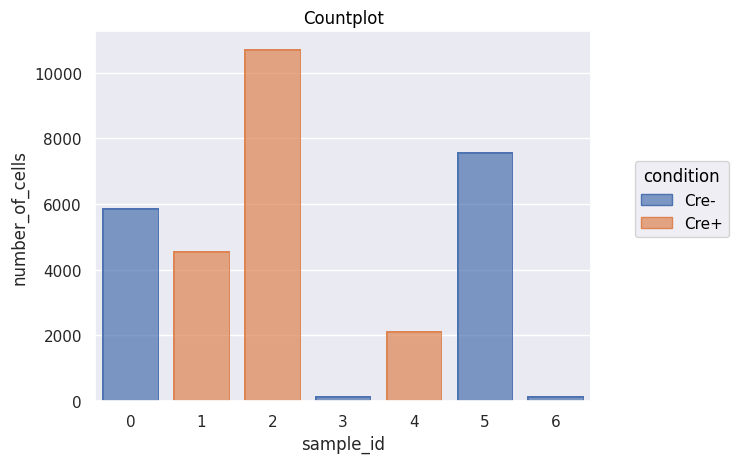

In [5]:
'''
A basic countplot shows that the data has been loaded
'''
fig = Analysis_experiment.plot_cell_counts(group_by = "sample_id", color_by = "condition", filename = "countplot.png")
fig

## Do Analysis steps on loaded data!

In [6]:
'''
Will begin by scaling the data -- let's try the qnorm method, it tends to very aggressively reshape the data
'''
Analysis_experiment.do_scaling("qnorm")

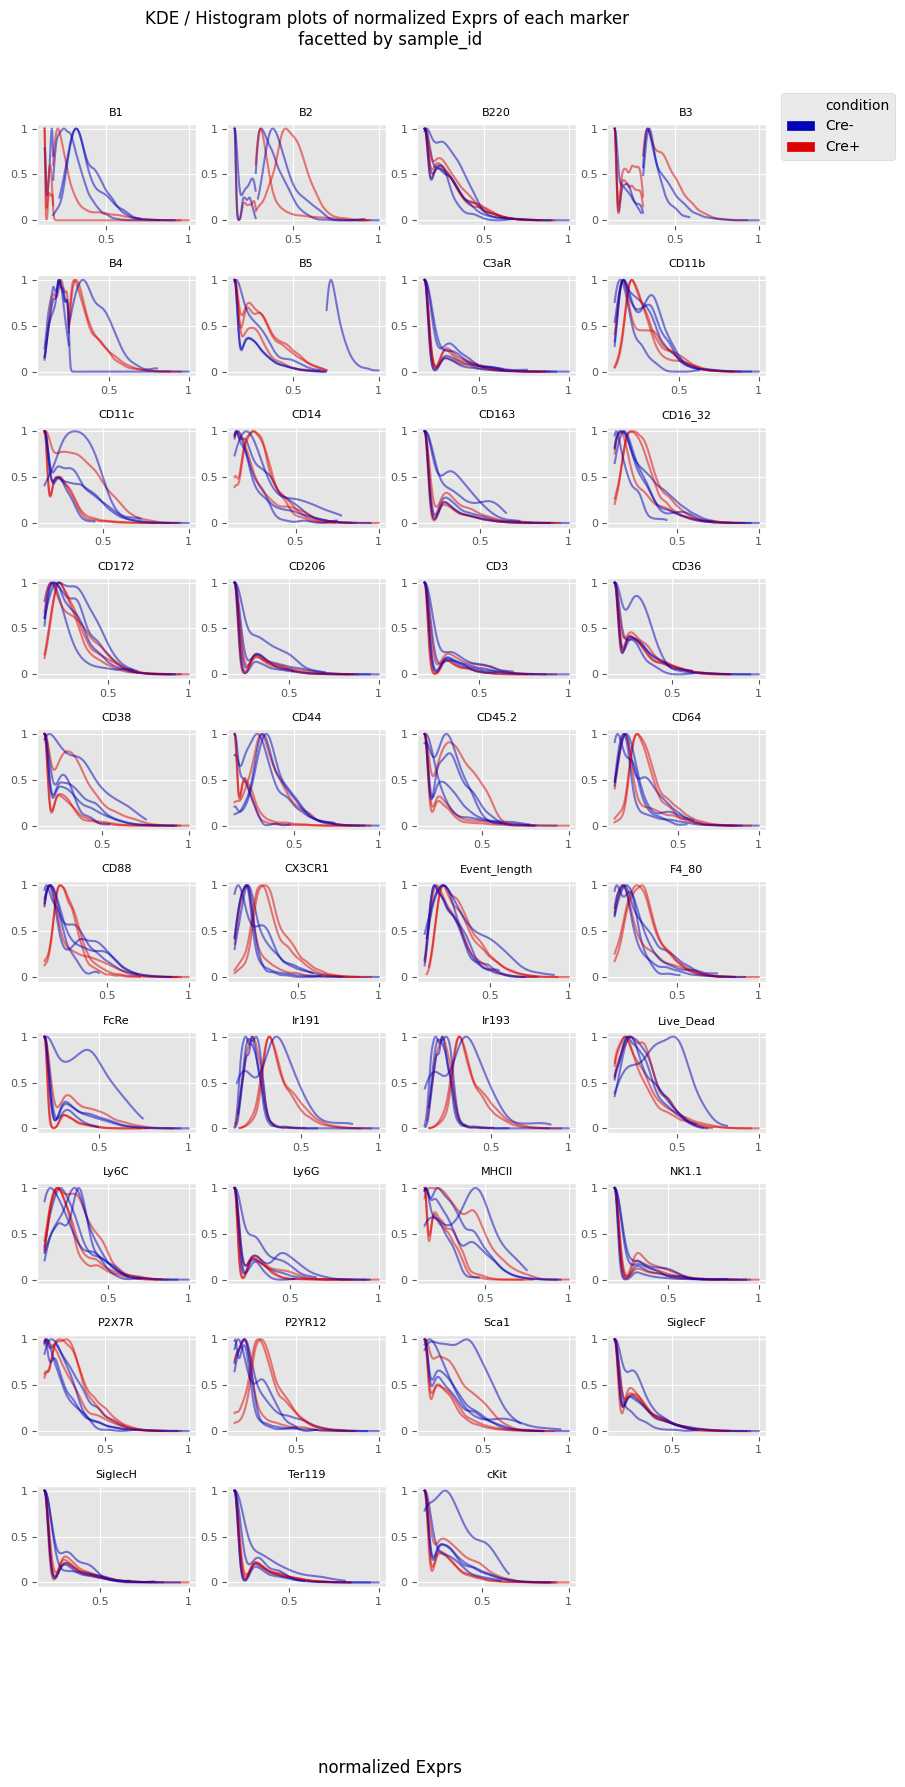

In [7]:
fig = Analysis_experiment.plot_ROI_histograms(filename = "sample_id_histo", color_by = "condition")
fig

## The cell clusteirngs from the exported data are still available

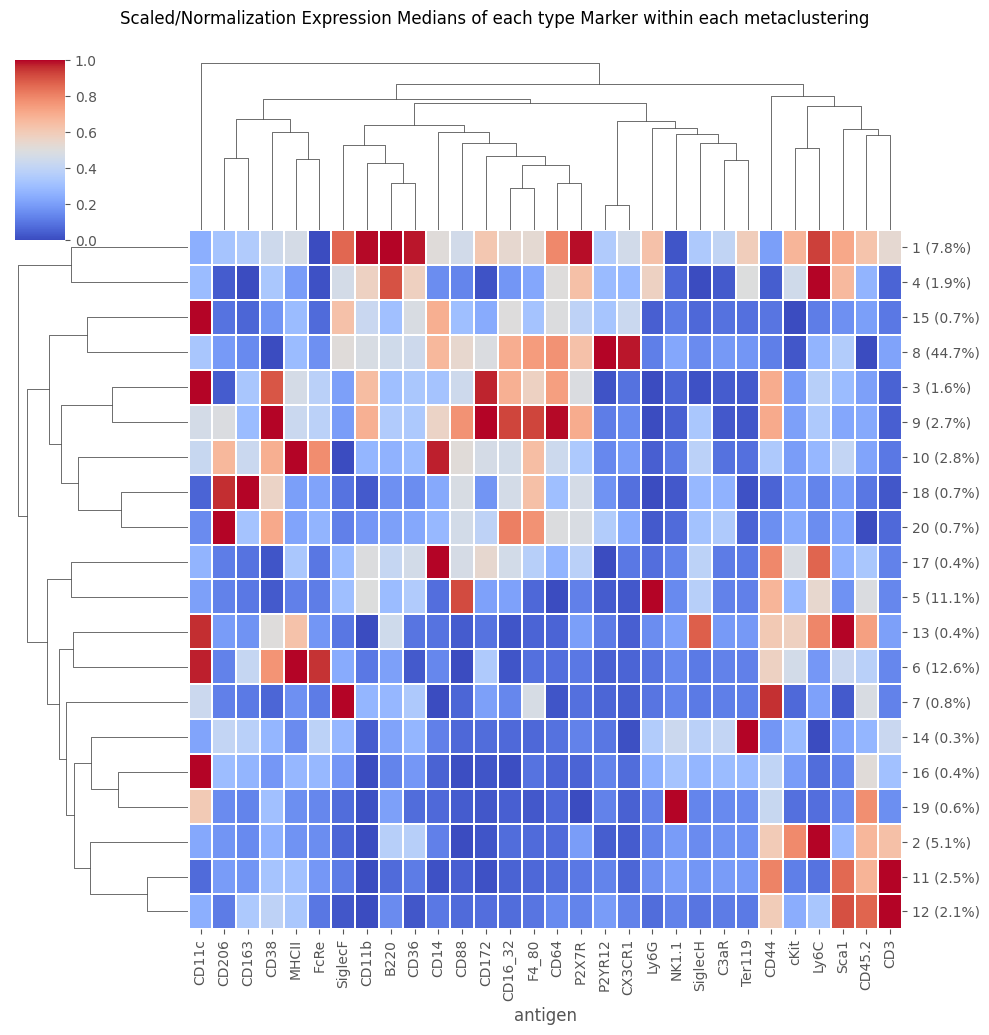

In [8]:
## Because we are reloading this from a previously exported CSV that already contains a metaclustering, we can plot that already
fig = Analysis_experiment.plot_medians_heatmap(filename = "heatmap", marker_class = "type", groupby = "metaclustering")
fig

## But we can still re-cluster the data if we like

Note, however, that this can overwrite the cell clusterings from the original data export -- as it does here

In [9]:
Analysis_experiment.do_flowsom(n_clusters = 20, XY_dim = 10, seed = 1234)

2025-02-21 16:36:32.864 | DEBUG    | palmettobug._vendor.flowsom:__init__:712 - Reading input.
2025-02-21 16:36:32.864 | DEBUG    | palmettobug._vendor.flowsom:__init__:714 - Fitting model: clustering and metaclustering.
2025-02-21 16:36:37.900 | DEBUG    | palmettobug._vendor.flowsom:__init__:716 - Updating derived values.


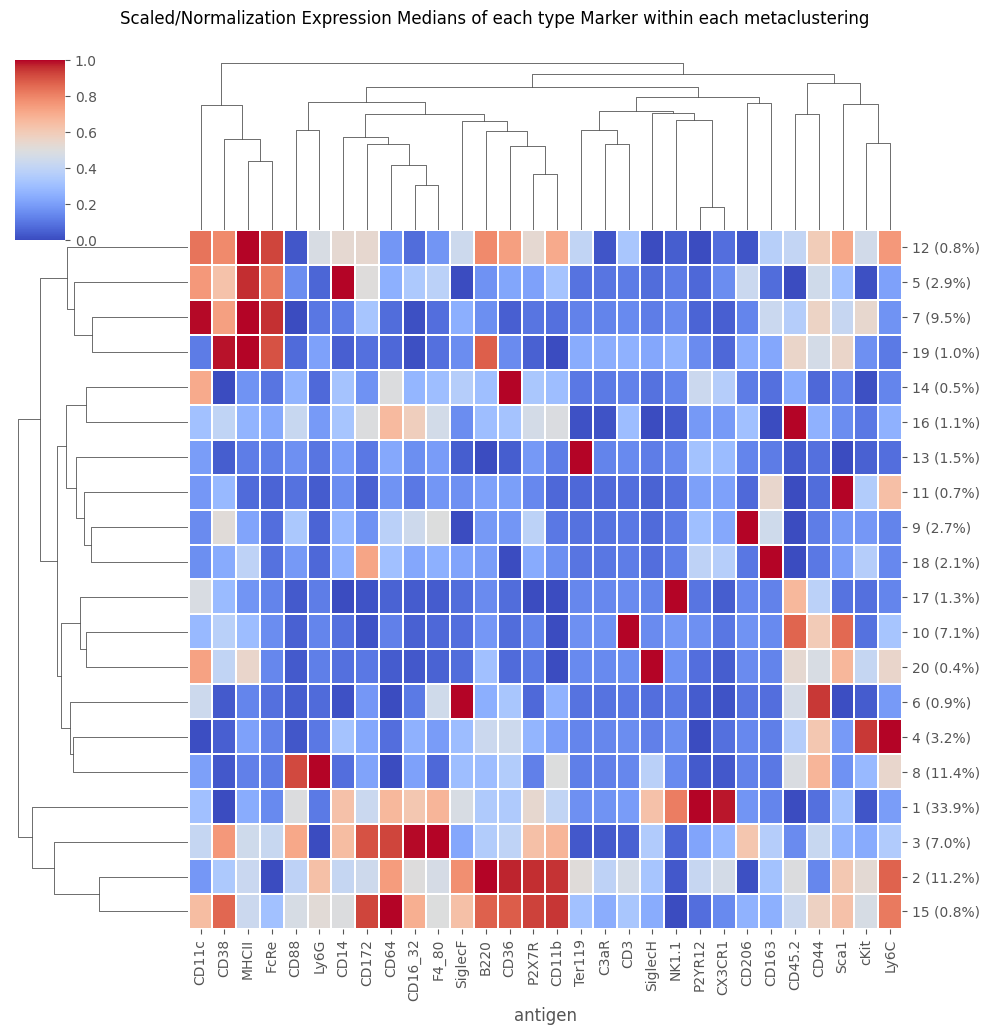

In [10]:
fig = Analysis_experiment.plot_medians_heatmap(filename = "heatmap", marker_class = "type", groupby = "metaclustering")
fig

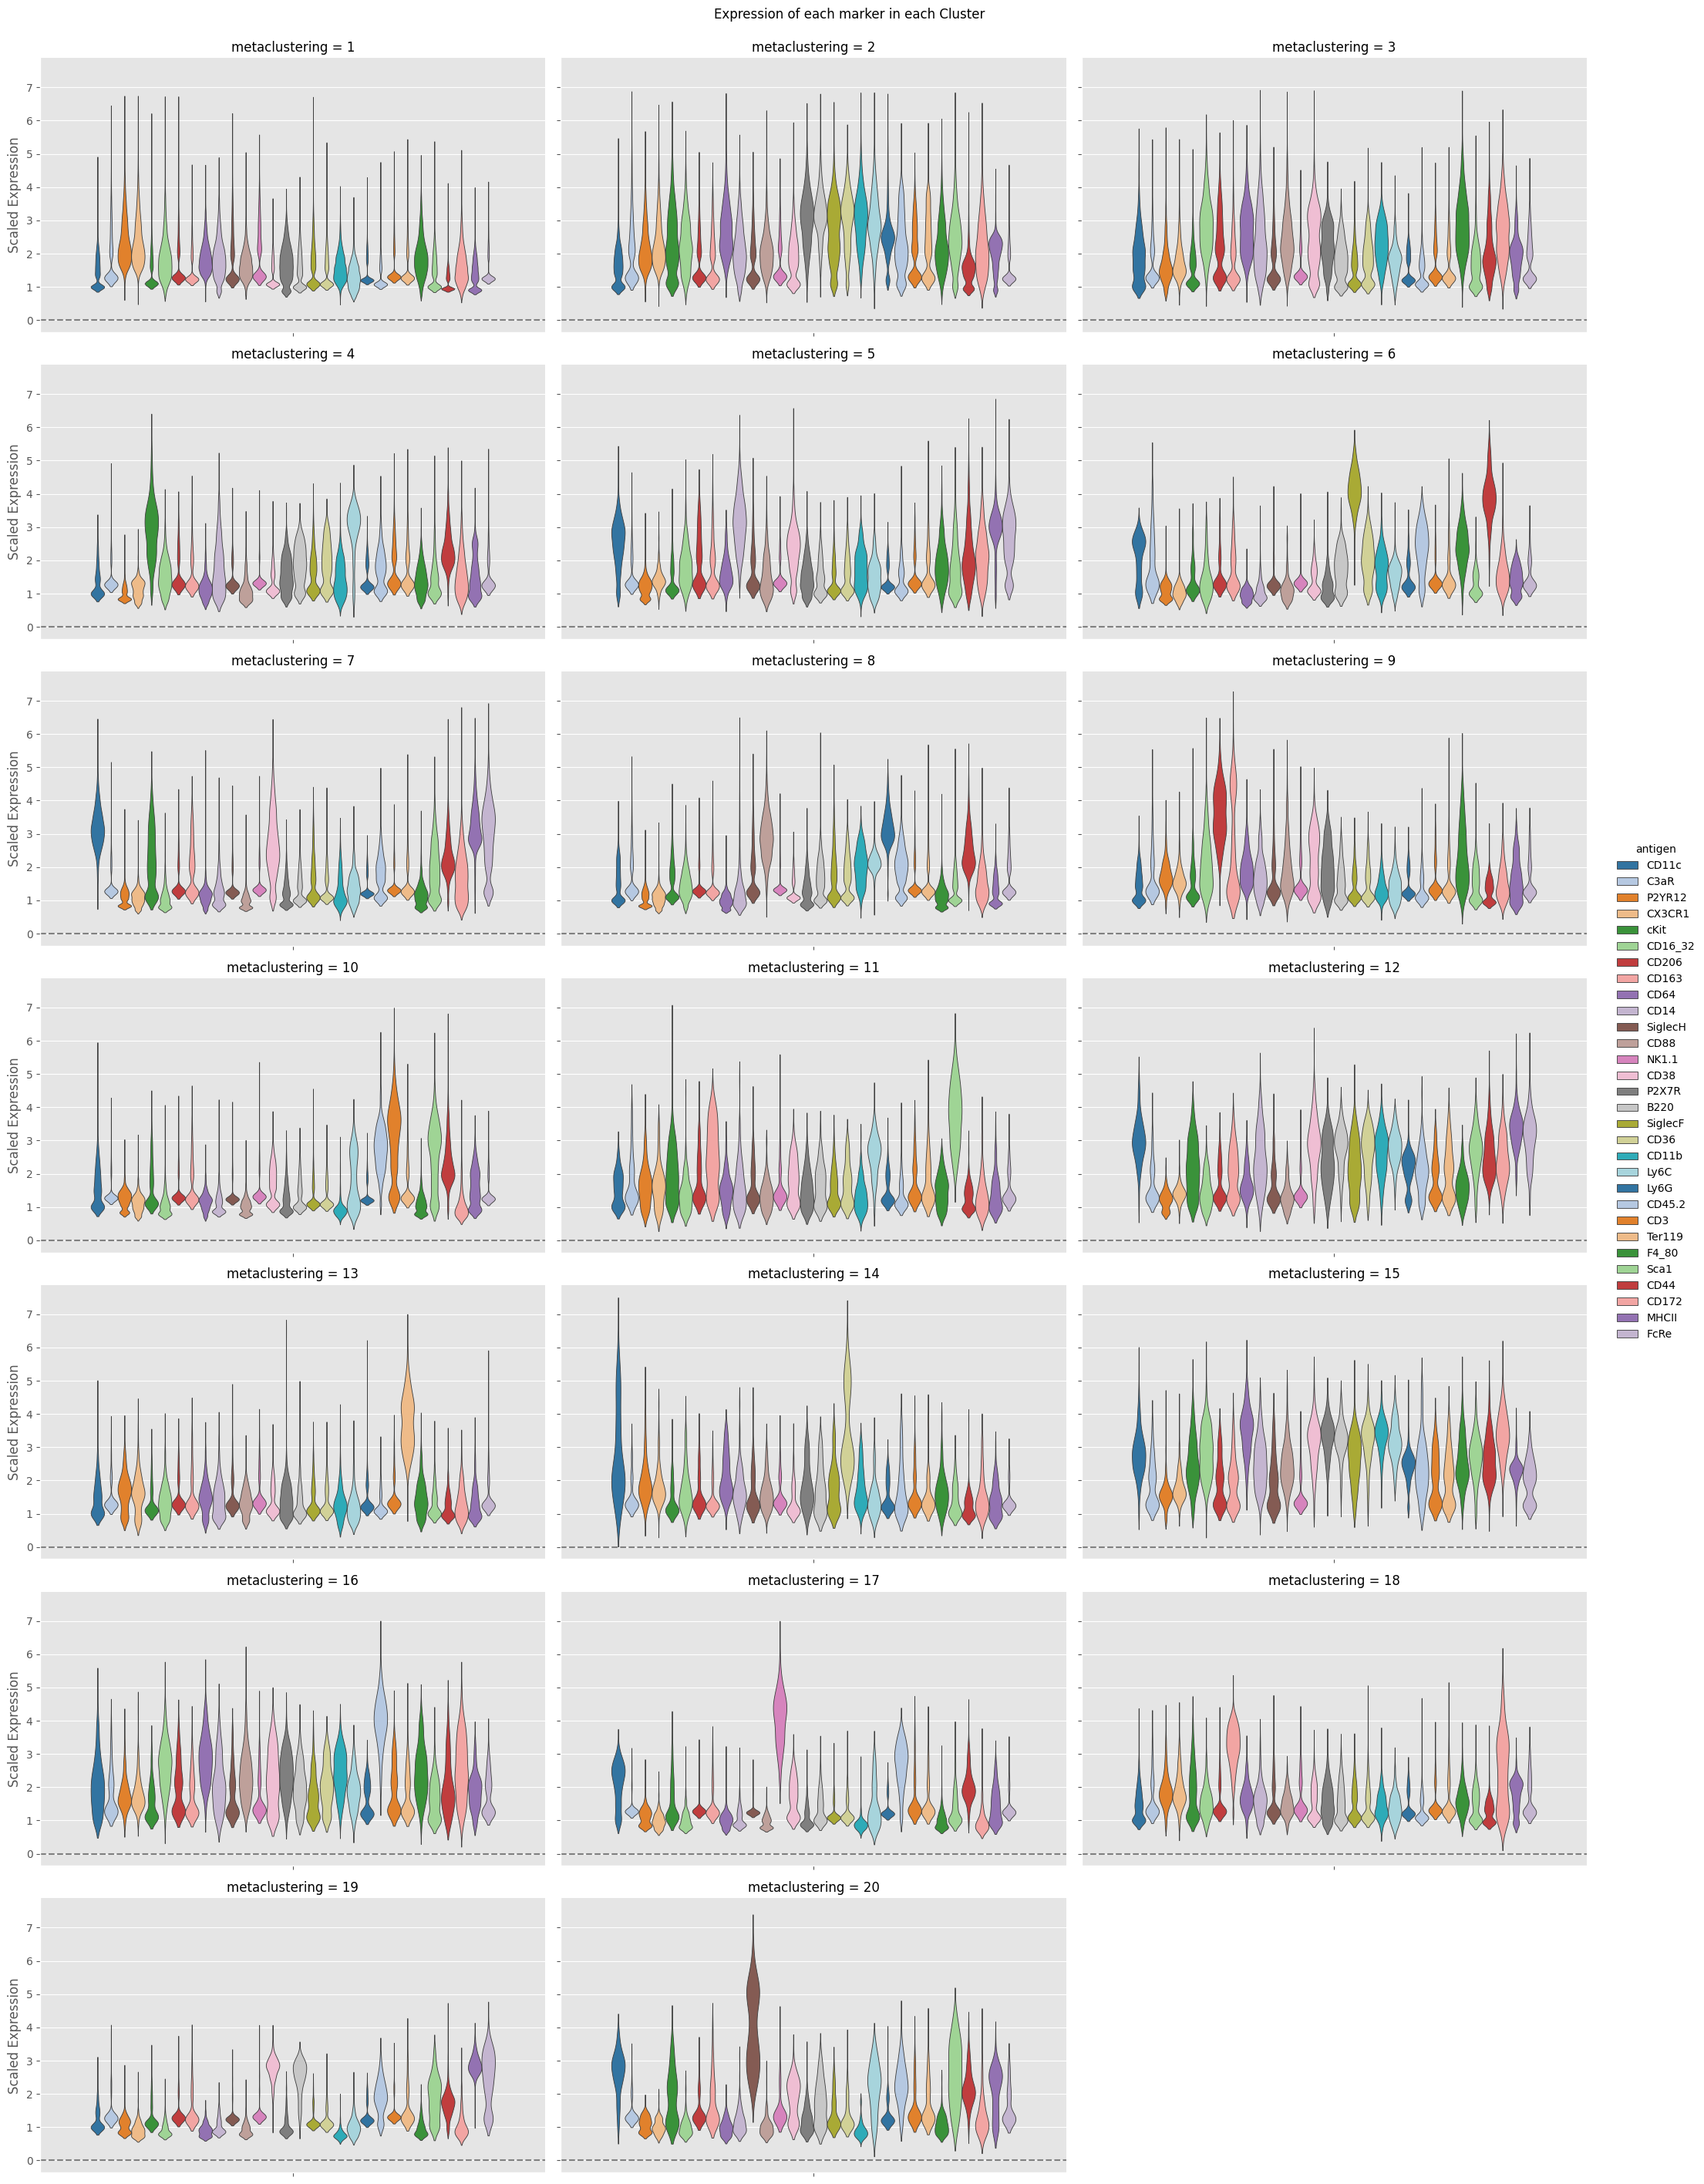

In [11]:
fig = Analysis_experiment.plot_cluster_distributions(filename = "violin", groupby_column = "metaclustering", marker_class = 'type', 
                                    plot_type = "violin", comp_type = "raw")
fig

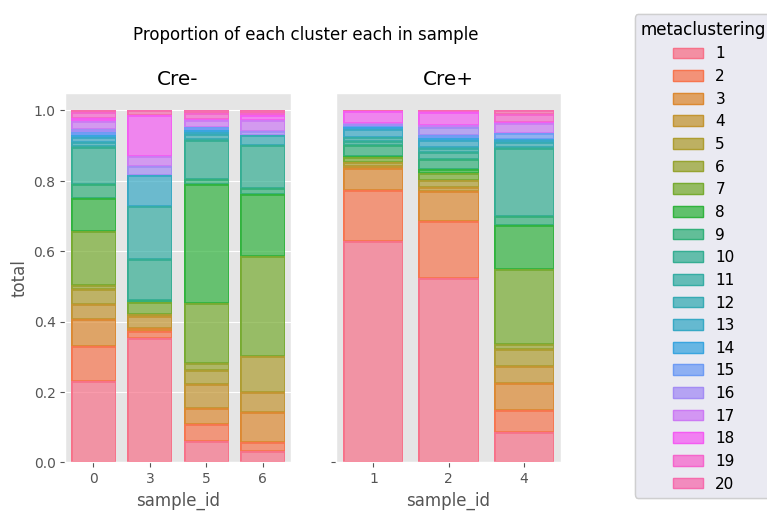

In [12]:
fig = Analysis_experiment.plot_cluster_abundance_1(filename = "abundance_boxplot", groupby_column = "metaclustering")   #, hue = "condition", plot_type = "boxplot")
fig